In [1]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo 
from matplotlib import pyplot as plt
from scipy.linalg import qr
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as colors


In [2]:
# fetch dataset 
communities_and_crime = fetch_ucirepo(id=183) 
  
# data (as pandas dataframes) 
X = communities_and_crime.data.features
y = communities_and_crime.data.targets
df = pd.concat([X, y], axis=1)
# change ? (missing value indicator) to NAs and drop columns with missing values
df.replace('?', pd.NA, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df_clean = df.dropna(axis=1)
# dropping these categorical columns rather than one-hot encoding them because 
# if we include only some of the one-hot encoded ones that's a bit weird
df_clean.drop(columns=["state", "fold"], inplace=True)
df_clean

/var/folders/4c/sh6kr5rx02jgqlwfm4gwl5cw0000gn/T/ipykernel_39028/147206845.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.drop(columns=["state", "fold"], inplace=True)


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.22,0.28,0.34,0.48,0.39,0.01,0.28,0.05,0.00,0.09
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.53,0.25,0.17,0.10,0.00,0.02,0.37,0.20,0.00,0.45
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.25,0.68,0.61,0.79,0.76,0.08,0.32,0.18,0.91,0.23
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.45,0.64,0.54,0.59,0.52,0.03,0.38,0.33,0.22,0.19


In [3]:
y_clean = df_clean[['ViolentCrimesPerPop']].values
X_clean = df_clean.drop(columns=['ViolentCrimesPerPop']).values
n, m = np.shape(X_clean)
# randomly order the data and the columns
idx = np.random.permutation(n)
X_clean = X_clean[idx]
y_clean = y_clean[idx]
# for random order:
ordering = 0
col_idx = np.random.permutation(m)
X_clean = X_clean[:, col_idx]

# for ordering by weight in theta_full
# ordering = 1
# theta_full = np.linalg.lstsq(X_clean, y_clean, rcond=None)[0]
# col_idx = np.argsort(theta_full.flatten())
# X_clean = X_clean[:, col_idx]

# for ordering by QR decomp of X_clean (M)
# ordering = 2
# _, R, P = qr(X_clean, pivoting=True)
# X_clean = X_clean[:, P]


In [4]:
# tracking stuff
error = np.zeros(m)
test_error = np.zeros(m)
norm_A = np.zeros(m)
norm_PN_theta = np.zeros(m)
norm_theta_U = np.zeros(m)
norm_A_theta_u = np.zeros(m - 1)
norm_pinv_MTM = np.zeros(m - 1)
first_spectral_val = np.zeros(m - 1)
second_spectral_val = np.zeros(m - 1)
independence = np.zeros(m - 1)
ranks = np.zeros(m - 1)

risk = np.zeros(m - 1)
N = 30
# calculating theta_full with all the data so it's closer to the true value
theta_full = np.linalg.lstsq(X_clean, y_clean, rcond=None)[0]
for i in range(1, m):
    # breaking up the matrix and vectors
    M_TM = X_clean[:N, :i]
    M_TU = X_clean[:N, i:]
    M_PM = X_clean[N:, :i]
    M_PU = X_clean[N:, i:]
    theta_M = theta_full[:i]
    theta_U = theta_full[i:]

    M_TM_pinv = np.linalg.pinv(M_TM)  
    theta_hat = M_TM_pinv @ y_clean[:N]
    
    y_hat = M_TM @ theta_hat
    y_test_hat = X_clean[N:, :i] @ theta_hat
    error[i] = np.linalg.norm(y_hat - y_clean[:N]) / N
    test_error[i] = np.linalg.norm(y_test_hat - y_clean[N:]) / (len(y_test_hat))
    risk[i - 1] = np.linalg.norm(np.vstack((y_hat, y_test_hat)) - y_clean)**2 / len(y_clean)
    
    A = M_TM_pinv @ M_TU
    norm_A[i] = np.linalg.norm(A, ord=2)
    
    B = M_TM_pinv @ M_TM
    PN = np.eye(i) - B
    if i > N:
        norm_PN_theta[i] = np.linalg.norm(PN@theta_M)
    
    norm_theta_U[i] = np.linalg.norm(theta_U)
    norm_A_theta_u[i - 1] = np.linalg.norm(A @ theta_U)

    norm_pinv_MTM[i - 1] = np.linalg.norm(M_TM_pinv, ord=2)
    U, s, Vh = np.linalg.svd(M_TM_pinv)
    first_spectral_val[i - 1] = s[0]
    if i > 1:
        second_spectral_val[i - 1] = s[1]
    if i < m:
        new_col = X_clean[:N, i:i+1]
        projection = M_TM @ np.linalg.pinv(M_TM) @ new_col
        residual = new_col - projection
        
        independence[i - 1] = np.linalg.norm(residual) / np.linalg.norm(new_col)
    ranks[i - 1] = np.linalg.matrix_rank(M_TM)

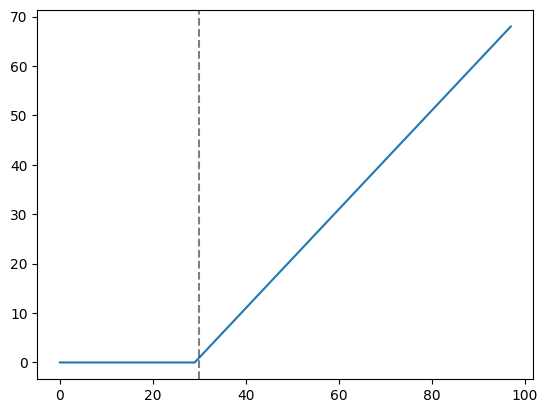

In [20]:
plt.plot(np.arange(1, m) - ranks)
plt.axvline([30], color='black', linestyle='--', alpha=0.5)


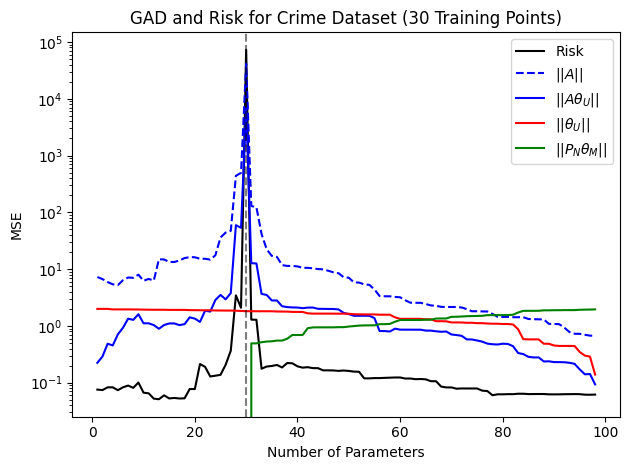

In [5]:
plt.semilogy(np.arange(1, m), risk, label='Risk', color="black")
# plt.semilogy(np.arange(1, m), error[1:], label="In-Sample Error")
plt.semilogy(np.arange(1, m), norm_A[1:], label=r"$|| A ||$", color="blue", linestyle='--')
plt.semilogy(np.arange(1, m), norm_A_theta_u, label=r"$|| A \theta_U||$", color="blue")
plt.semilogy(np.arange(1, m), norm_theta_U[1:], label=r"$||\theta_U||$", color="red")
plt.semilogy(np.arange(1, m), norm_PN_theta[1:], label=r"||$P_N \theta_M$||", color="green")

plt.title(f"GAD and Risk for Crime Dataset ({N} Training Points)")
plt.xlabel("Number of Parameters")
plt.ylabel("MSE")
plt.axvline([N], color='black', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
if ordering == 0:
    plt.savefig(f'./plots/gad183_{N}points.jpg')
if ordering == 1:
    plt.savefig(f'./plots/ordered_gad183_{N}points.jpg')
if ordering == 2:
    plt.savefig(f'./plots/qr_ordered_gad183_{N}points.jpg')
plt.show()

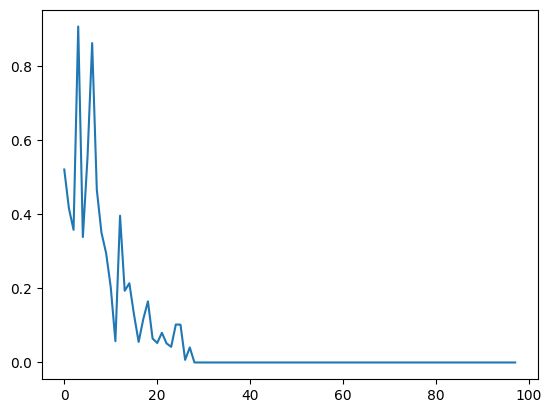

In [6]:
plt.plot(independence)

what percentage of variation in risk is explained by variation in other things?

Text(0, 0.5, 'norm of $\\theta_U$')

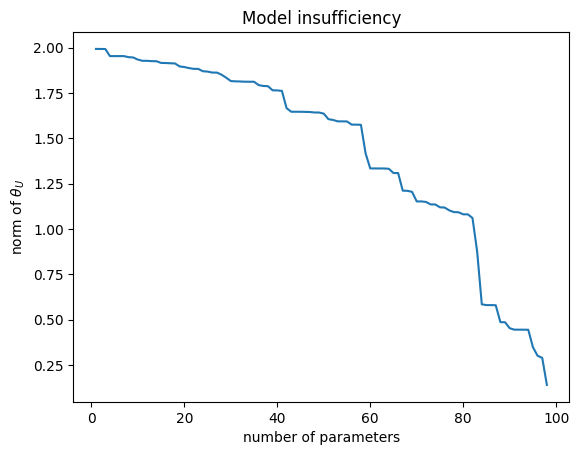

In [7]:
plt.title("Model insufficiency")
plt.plot(np.arange(1, m), norm_theta_U[1:])
plt.xlabel("number of parameters")
plt.ylabel(r"norm of $\theta_U$")
# this should be monotonically decreasing!

Text(0, 0.5, 'norm of $PN_\\theta$')

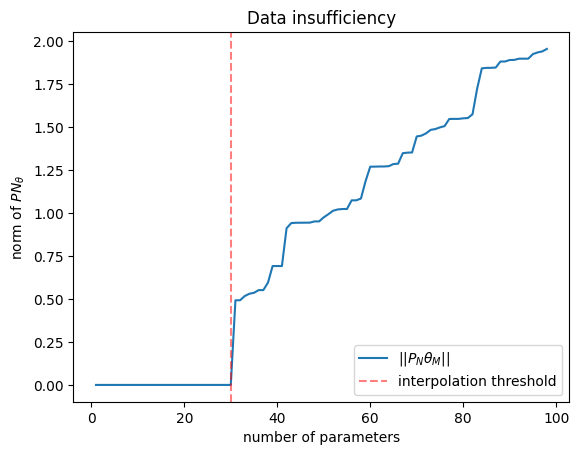

In [8]:
plt.title("Data insufficiency")
plt.plot(np.arange(1, m), norm_PN_theta[1:], label=r"||$P_N \theta_M$||")
plt.xlabel("number of parameters")
plt.axvline([N], label="interpolation threshold", color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.ylabel(r"norm of $PN_\theta$")
# this should be monotonically increasing (after interpolation)

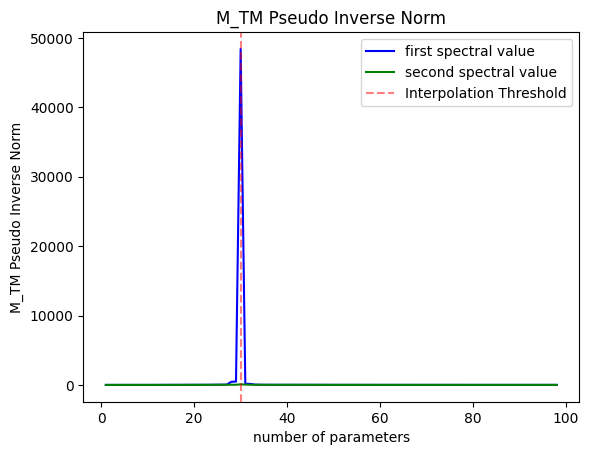

In [9]:
plt.title("M_TM Pseudo Inverse Norm")
plt.plot(np.arange(1, m), norm_pinv_MTM, label='first spectral value', color='blue')
plt.plot(np.arange(1, m), second_spectral_val, label="second spectral value", color='green')
plt.xlabel("number of parameters")
plt.ylabel("M_TM Pseudo Inverse Norm")
plt.axvline([N], label="Interpolation Threshold", color='red', linestyle='--', alpha=0.5)
plt.legend()

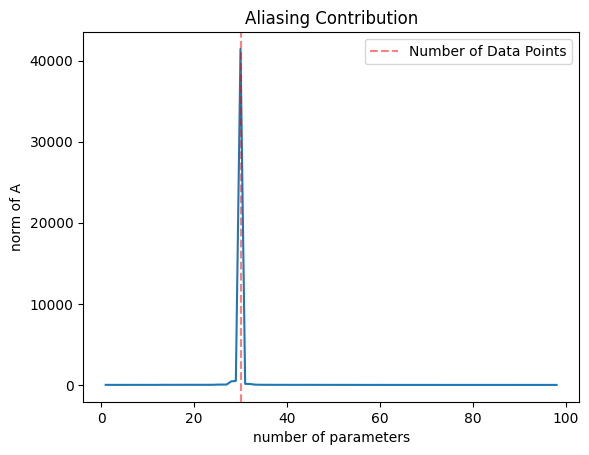

In [10]:
plt.title("Aliasing Contribution")
plt.plot(np.arange(1, m), norm_A[1:])
plt.xlabel("number of parameters")
plt.ylabel(r"norm of A")
plt.axvline([N], label="Number of Data Points", color='red', linestyle='--', alpha=0.5)
plt.legend()

In [11]:
norm_A = np.zeros((m, 100))
norm_PN_theta = np.zeros((m, 100))
norm_theta_U = np.zeros((m, 100))
norm_A_theta_u = np.zeros((m - 1, 100))
risk = np.zeros((m - 1, 100))

for j in range(1, 100):
    for i in range(1, m):
        N = j
        M_TM = X_clean[:N, :i]
        M_TU = X_clean[:N, i:]
        M_PM = X_clean[N:, :i]
        M_PU = X_clean[N:, i:]
        theta_M = theta_full[:i]
        theta_U = theta_full[i:]

        M_TM_pinv = np.linalg.pinv(M_TM)  
        theta_hat = M_TM_pinv @ y_clean[:N]
        
        y_hat = M_TM @ theta_hat
        y_test_hat = X_clean[N:, :i] @ theta_hat
        risk[i - 1, j] = np.linalg.norm(np.vstack((y_hat, y_test_hat)) - y_clean)**2 / len(y_clean)
        
        A = M_TM_pinv @ M_TU
        norm_A[i, j] = np.linalg.norm(A, ord=2)
        
        B = M_TM_pinv @ M_TM
        PN = np.eye(i) - B
        if i > N:
            norm_PN_theta[i, j] = np.linalg.norm(PN@theta_M)
        
        norm_theta_U[i, j] = np.linalg.norm(theta_U)
        norm_A_theta_u[i - 1, j] = np.linalg.norm(A @ theta_U)

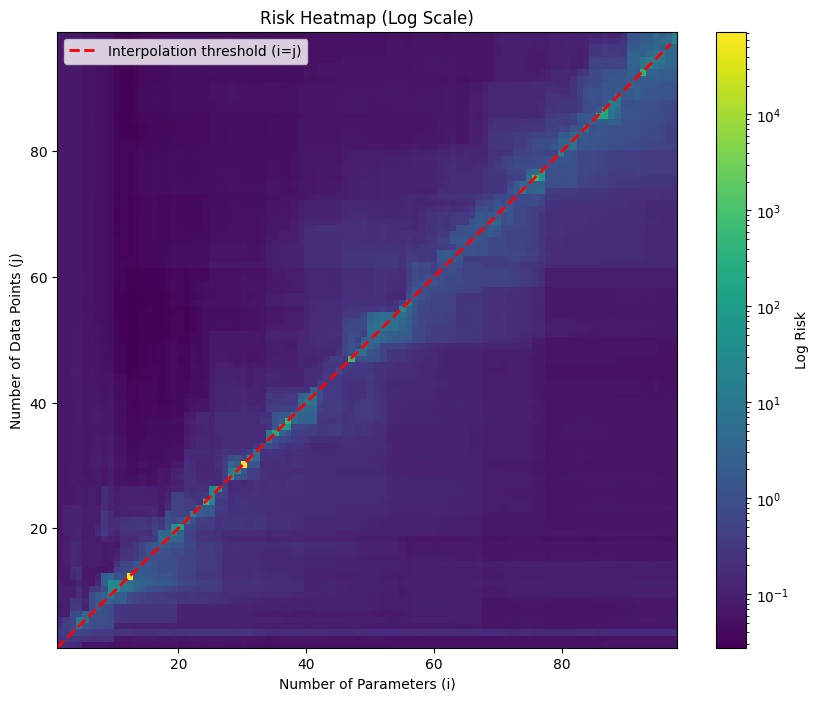

In [12]:

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(risk[:, 1:].T, aspect='auto', origin='lower',
               extent=[1, m-1, 1, 99],
               cmap='viridis',
               norm=colors.LogNorm(vmin=risk[:, 1:][risk[:, 1:] > 0].min(), 
                                   vmax=risk[:, 1:].max()))

# Interpolation threshold diagonal
thresh = np.arange(1, min(m-1, 99))
ax.plot(thresh, thresh, color='red', linewidth=2,
        linestyle='--', label='Interpolation threshold (i=j)')

fig.colorbar(im, label='Log Risk')
ax.set_xlabel('Number of Parameters (i)')
ax.set_ylabel('Number of Data Points (j)')
ax.set_title('Risk Heatmap (Log Scale)')
ax.legend()
plt.show()


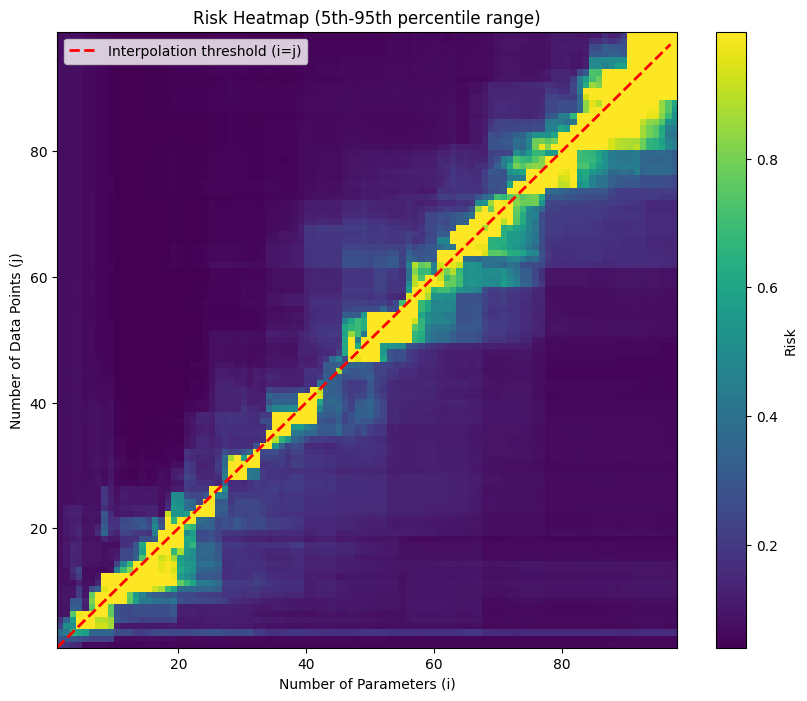

In [13]:
risk_plot = risk[:, 1:].T
vmin = np.percentile(risk_plot[risk_plot > 0], 5)
vmax = np.percentile(risk_plot, 95)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(risk_plot, aspect='auto', origin='lower',
               extent=[1, m-1, 1, 99],
               cmap='viridis',
               vmin=vmin, vmax=vmax)

thresh = np.arange(1, min(m-1, 99))
ax.plot(thresh, thresh, color='red', linewidth=2,
        linestyle='--', label='Interpolation threshold (i=j)')

fig.colorbar(im, label='Risk')
ax.set_xlabel('Number of Parameters (i)')
ax.set_ylabel('Number of Data Points (j)')
ax.set_title('Risk Heatmap (5th-95th percentile range)')
ax.legend()
if ordering == 0:
    plt.savefig(f'./plots/risk183_{N}points.jpg')
if ordering == 1:
    plt.savefig(f'./plots/ordered_risk183_{N}points.jpg')
if ordering == 2:
    plt.savefig(f'./plots/qr_ordered_risk183_{N}points.jpg')
plt.show()


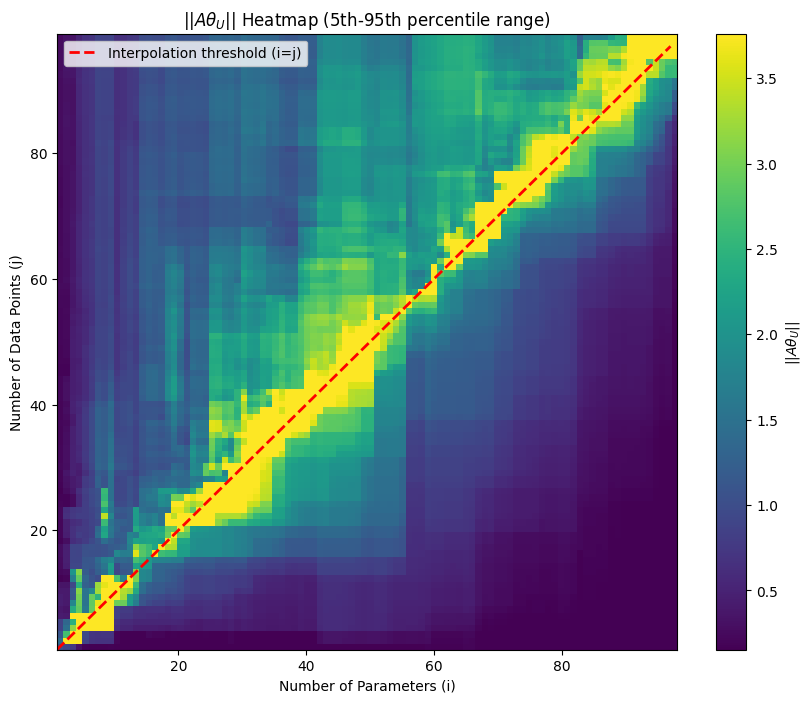

In [14]:
a_plot = norm_A_theta_u[:, 1:].T
vmin = np.percentile(a_plot[a_plot > 0], 5)
vmax = np.percentile(a_plot, 95)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(a_plot, aspect='auto', origin='lower',
               extent=[1, m-1, 1, 99],
               cmap='viridis',
               vmin=vmin, vmax=vmax)

thresh = np.arange(1, min(m-1, 99))
ax.plot(thresh, thresh, color='red', linewidth=2,
        linestyle='--', label='Interpolation threshold (i=j)')

fig.colorbar(im, label=r"$|| A \theta_U||$")
ax.set_xlabel('Number of Parameters (i)')
ax.set_ylabel('Number of Data Points (j)')
ax.set_title(r'$|| A \theta_U||$ Heatmap (5th-95th percentile range)')
ax.legend()

if ordering == 0:
    plt.savefig(f'./plots/alias183_{N}points.jpg')
if ordering == 1:
    plt.savefig(f'./plots/ordered_alias183_{N}points.jpg')
if ordering == 2:
    plt.savefig(f'./plots/qr_ordered_alias183_{N}points.jpg')
plt.show()


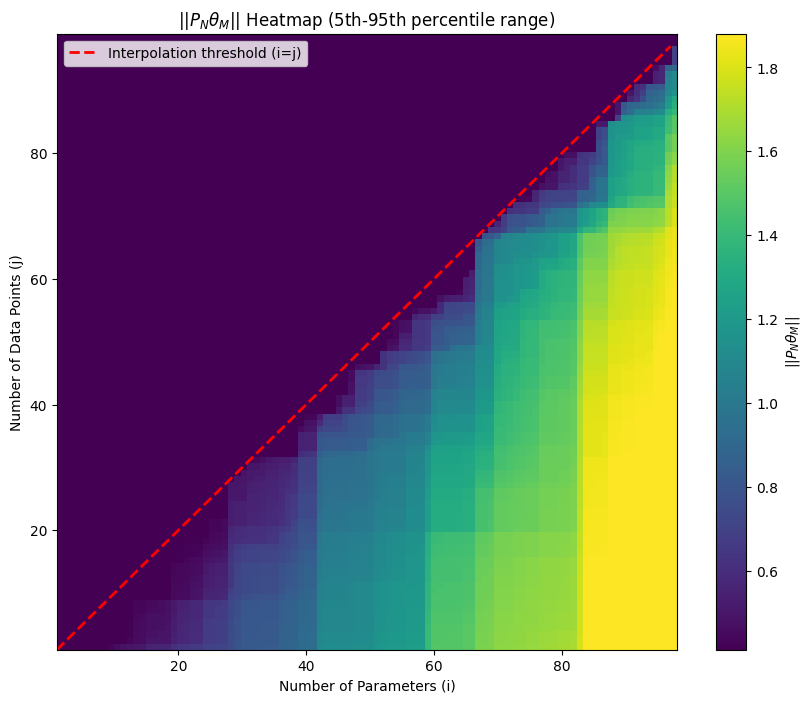

In [15]:
pn_plot = norm_PN_theta[1:, 1:].T
vmin = np.percentile(pn_plot[pn_plot > 0], 5)
vmax = np.percentile(pn_plot, 95)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(pn_plot, aspect='auto', origin='lower',
               extent=[1, m-1, 1, 99],
               cmap='viridis',
               vmin=vmin, vmax=vmax)

thresh = np.arange(1, min(m-1, 99))
ax.plot(thresh, thresh, color='red', linewidth=2,
        linestyle='--', label='Interpolation threshold (i=j)')

fig.colorbar(im, label=r"||$P_N \theta_M$||")
ax.set_xlabel('Number of Parameters (i)')
ax.set_ylabel('Number of Data Points (j)')
ax.set_title(r"||$P_N \theta_M$|| Heatmap (5th-95th percentile range)")
ax.legend()

if ordering == 0:
    plt.savefig(f'./plots/pn183_{N}points.jpg')
if ordering == 1:
    plt.savefig(f'./plots/ordered_pn183_{N}points.jpg')
if ordering == 2:
    plt.savefig(f'./plots/qr_ordered_pn183_{N}points.jpg')
plt.show()

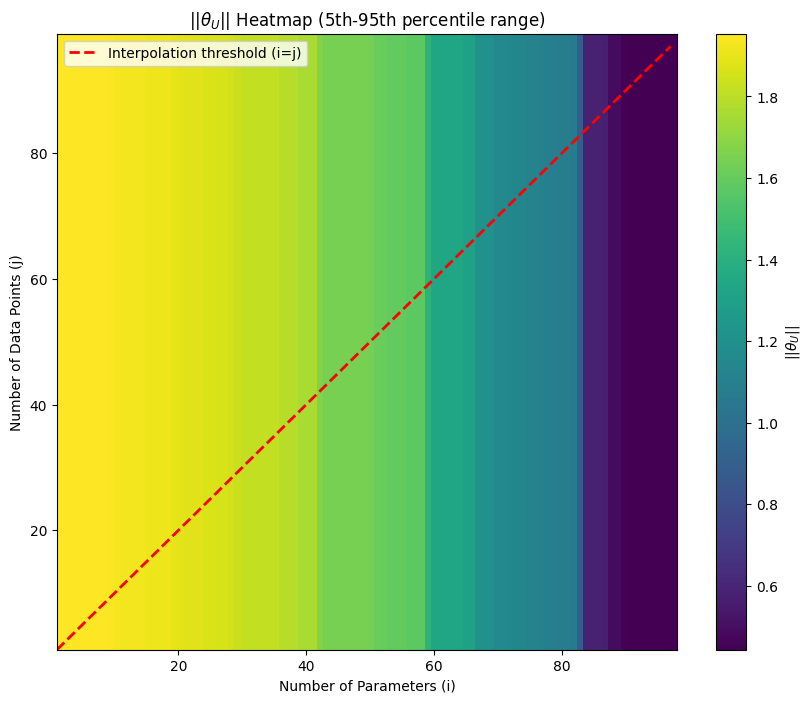

In [16]:
pn_plot = norm_theta_U[1:, 1:].T
vmin = np.percentile(pn_plot[pn_plot > 0], 5)
vmax = np.percentile(pn_plot, 95)

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(pn_plot, aspect='auto', origin='lower',
               extent=[1, m-1, 1, 99],
               cmap='viridis',
               vmin=vmin, vmax=vmax)

thresh = np.arange(1, min(m-1, 99))
ax.plot(thresh, thresh, color='red', linewidth=2,
        linestyle='--', label='Interpolation threshold (i=j)')

fig.colorbar(im, label=r"$||\theta_U||$")
ax.set_xlabel('Number of Parameters (i)')
ax.set_ylabel('Number of Data Points (j)')
ax.set_title(r"$||\theta_U||$ Heatmap (5th-95th percentile range)")
ax.legend()

if ordering == 0:
    plt.savefig(f'./plots/model183_{N}points.jpg')
if ordering == 1:
    plt.savefig(f'./plots/ordered_model183_{N}points.jpg')
if ordering == 2:
    plt.savefig(f'./plots/qr_ordered_model183_{N}points.jpg')
plt.show()